## Review 
### 1. 파이프 만들기
- pipeline.pkl에 파이프라인 저장

In [7]:
import os
os.getcwd()

'c:\\Users\\user\\Desktop\\1.Lecture\\1.교육\\0. 2026\\1.한화\\2.ML\\1주차'

In [8]:
import pandas as pd
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pickle

# CSV 읽기
csv_path = "data.csv"      # <- 파일명 수정
target_col = "Pass.Fail"      # <- 타깃 컬럼명 수정

df = pd.read_csv(csv_path)

X = df.drop(columns=[target_col])
y = df[target_col]

# 전처리(결측치 + 스케일링 + 원핫)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selector(dtype_include="number")),
        ("cat", categorical_transformer, selector(dtype_exclude="number"))
    ],
    remainder="drop"
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess)
])

with open("pipeline.pkl", "wb") as f:
    pickle.dump( { "pipeline": pipe},  f )
    
# 적용
X_piped = pipe.fit_transform(X)
X_processed = pd.DataFrame(X_piped, columns=X.columns)
X_processed[target_col] = y.values



### 2. duckdb 사용

In [9]:
!pip install duckdb

In [12]:
#파일 기반
import duckdb
con = duckdb.connect("example_ML.duckdb")

In [13]:
con.execute("""
CREATE TABLE model_result AS
SELECT * FROM df
""")


In [21]:
df_out = con.execute("""
SELECT *
FROM model_result
""").df()

print(df_out)


         X20     X86     X87        X88    X113      X115    X116     X117  \
0     1.4026  2.3895  0.9690  1747.6049  0.9460  748.6115  0.9908  58.4306   
1     1.3825  2.3754  0.9894  1931.6464  0.9425  731.2517  0.9902  58.6680   
2     1.4123  2.4532  0.9880  1685.8514  0.9231  718.5777  0.9899  58.4808   
3     1.4011  2.4004  0.9904  1752.0968  0.9564  709.0867  0.9906  58.6635   
4     1.3888  2.4530  0.9902  1828.3846  0.9424  796.5950  0.9908  58.3858   
...      ...     ...     ...        ...     ...       ...     ...      ...   
1562  1.4072  2.3762  0.9861  1869.4215  0.9520  727.6761  0.9894  58.3514   
1563  1.3949  2.4880  0.9911  1872.5133  0.9561  755.7527  0.9899  57.1020   
1564  1.4256  2.4590  0.9869  1820.3629  0.9488  704.2686  0.9891  59.2046   
1565  1.3868  2.3600  0.9796  1627.4714  0.9485  605.6190  0.9896  58.2686   
1566  1.4048  2.3701  0.9758  1759.9908  0.9432  683.5622  0.9893  59.8578   

        X119    X120  ...    X527      X570    X571   X572    X

- Insert

In [23]:
con.execute("""
INSERT INTO model_result
SELECT * FROM df
""")

- 테이블 등록 및 확인

In [ ]:
con.register("tmp_df", df)
con.execute("CREATE TABLE t AS SELECT * FROM tmp_df")

In [25]:
df2 = con.execute("SELECT * FROM t").df()

In [27]:
con.execute("SHOW TABLES").df()

,name
0,model_result
1,t
2,tmp_df


In [28]:
con.execute("DROP TABLE IF EXISTS model_result")

# 탐색적 자료 분석

Text(0.5, 1.0, 'Boxplot')

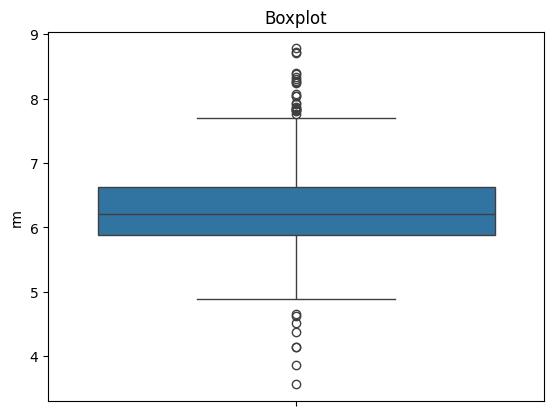

In [29]:
#Box plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

boston = pd.read_csv("BostonHousing.csv")[['rm', 'lstat', 'crim']]

sns.boxplot(y=boston['rm'])
plt.title('Boxplot')


In [30]:
#outlier 제거하기
#boxplot의 IQR(Q3-Q1)의 1.5배를 넘는 값들을 제거
def find_boundaries(df, variable, distance):
	IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
	lower_boundary = df[variable].quantile(0.25) - (IQR * distance)
	upper_boundary = df[variable].quantile(0.75) + (IQR * distance)
	return upper_boundary, lower_boundary

upper_boundary, lower_boundary = find_boundaries(boston, 'rm', 1.5)
upper_boundary, lower_boundary

(np.float64(7.730500000000001), np.float64(4.778499999999999))

In [31]:
a=np.array( [ 2,3,4,5])
print( a > 3 )
np.where( a>3, "A" ,  "B" )
~(a>3)

[False False  True  True]


array([ True,  True, False, False])

In [32]:
outliers = np.where(boston['rm'] > upper_boundary, True,
                    np.where(boston['rm'] < lower_boundary, True, False)
                    )
~outliers
boston['rm'][~outliers]  #outlier만 출력, T,F로 해당 위치의 값을 선택...

0      6.575
1      6.421
2      7.185
3      6.998
4      7.147
       ...  
501    6.593
502    6.120
503    6.976
504    6.794
505    6.030
Name: rm, Length: 476, dtype: float64

In [33]:
outliers_df = boston.loc[outliers, 'rm']  #iloc는 정수값...
outliers_df.head()

#outlier 실제로 제거해보기
boston.loc[~outliers, 'rm']

0      6.575
1      6.421
2      7.185
3      6.998
4      7.147
       ...  
501    6.593
502    6.120
503    6.976
504    6.794
505    6.030
Name: rm, Length: 476, dtype: float64

In [35]:
#crim 변수에서 중앙값보다 크거나, q1보다 작은 값들만 선택하세요
#np.where를 이용하세요
q1 = boston.crim.quantile(0.25)  #Q1
q2 = boston.crim.quantile(0.5)  #Q2, 중앙값
abc = np.where( boston.crim > q2  , True   ,
         np.where( boston.crim < q1, True, False )
         )

boston.crim[abc]
boston.loc[ abc, "crim"]


0      0.00632
1      0.02731
2      0.02729
3      0.03237
4      0.06905
        ...   
497    0.26838
501    0.06263
502    0.04527
503    0.06076
505    0.04741
Name: crim, Length: 380, dtype: float64

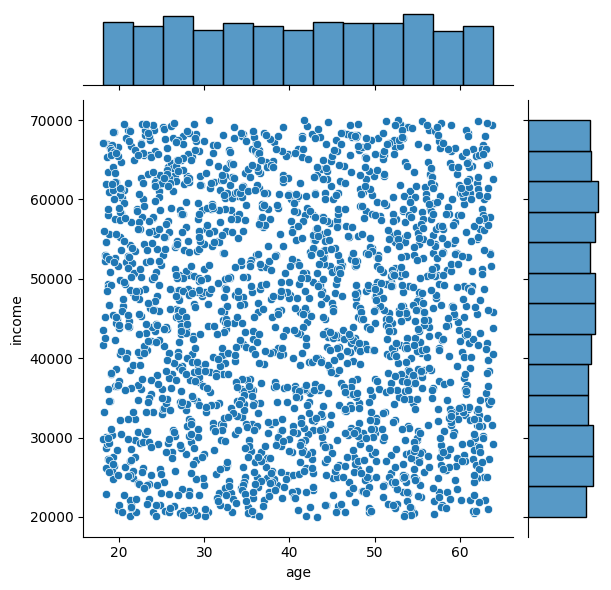

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = pd.read_csv("creditset2.csv")
join1 = sns.jointplot(x="age", y="income", data=data);
join1.savefig("join1.png")

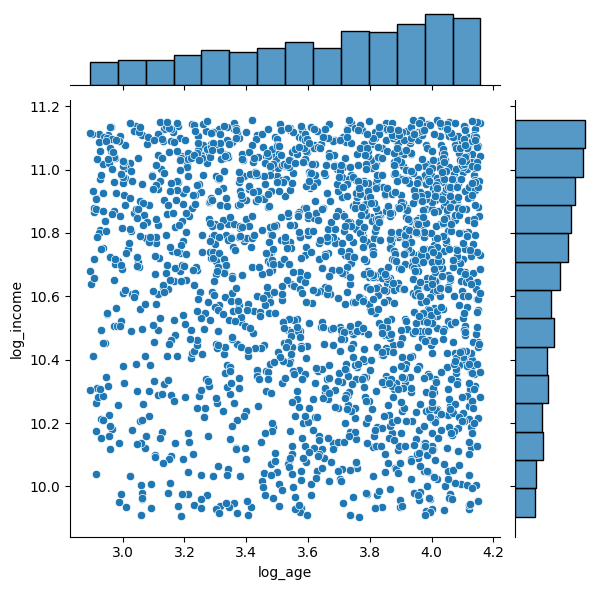

In [37]:
data["log_age"] = np.log( data.age )
data["log_income"] =np.log( data.income)

join1 = sns.jointplot(x="log_age", y="log_income", data=data);
join1.savefig("join1_log.jpg")

- tips데이터 연습

In [38]:
#tips 예제 데이터로 연습
plt.clf()
tips = sns.load_dataset('tips')
sns.set_style("whitegrid")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Figure size 640x480 with 0 Axes>

<Axes: >

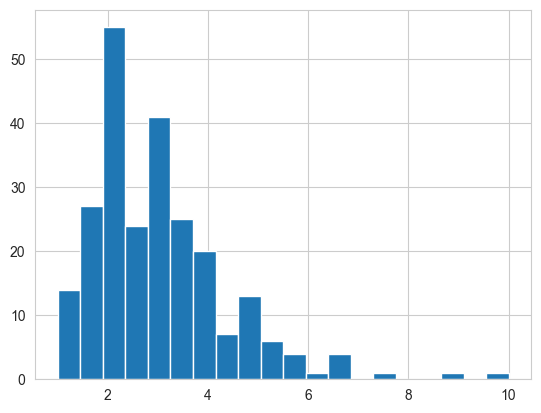

In [39]:
#tips 자료에서 total_bill, tip 사이의 corr를 구하고, p-value 확인
from scipy import stats
stats.pearsonr( tips.total_bill, tips.tip)
#요일별 빈도 체크
tips.day.value_counts()
#tip에 대한 histogram
tips.tip.hist( bins = 20 )

- tips 데이터에서, time별로 total_bill의 박스플랏
- 각 boxplot은 성별로 나눠서 표현 (hue를 지정)

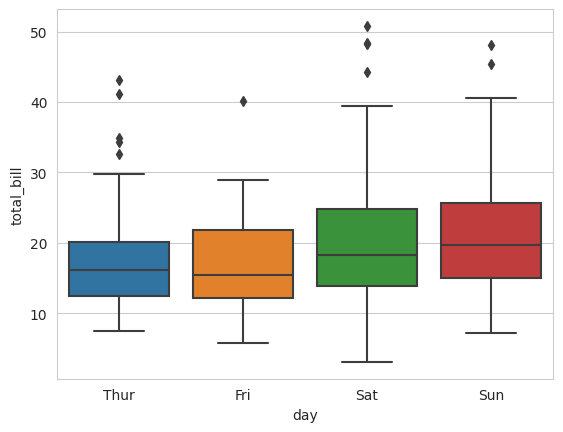

In [ ]:
#box plot
sns.boxplot(x="day", y="total_bill", data=tips)
plt.show()

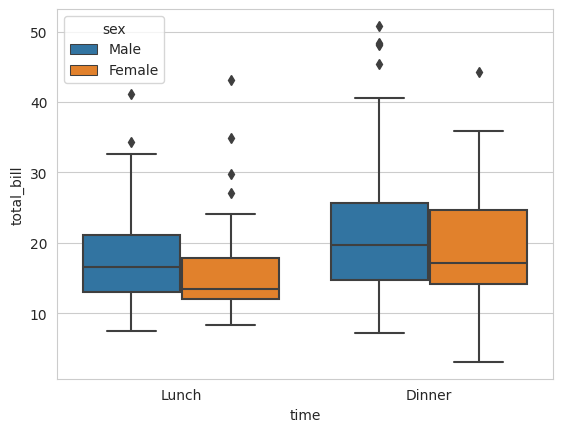

In [ ]:
#box plot
sns.boxplot(x="time", y="total_bill", hue="sex", data=tips)
plt.show()

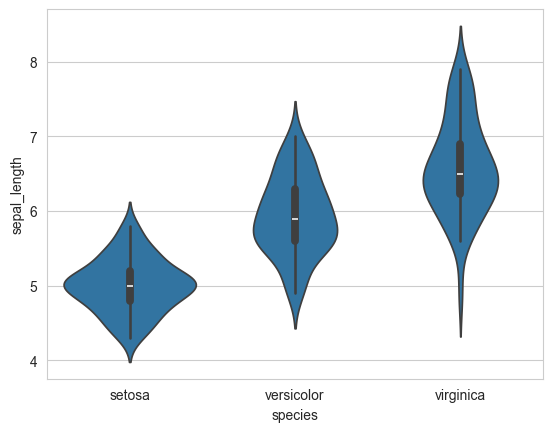

In [43]:
#violin plot
iris = sns.load_dataset("iris")
sns.violinplot(x=iris.species, y=iris.sepal_length, data=iris);
plt.savefig("violin.png")

In [ ]:
#pivot+Heatmap
#pivot
df1 = pd.DataFrame( {'x':['A','B', 'C', 'D', 'E', 'F'], 'y':[2021,2021,2021,2022,2022,2022], 'z':[1,2,3,4,5,6]})
df1.pivot(index='x',columns='y', values='z').fillna(0) #index 중복 없어야 함.

y,2021,2022
x,,
A,1.0,0.0
B,2.0,0.0
C,3.0,0.0
D,0.0,4.0
E,0.0,5.0
F,0.0,6.0


In [ ]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [ ]:
df = flights.pivot('month', 'year', 'passengers') #행, 열 지정, 값 지정
df.head()

<ipython-input-88-dc9017967813>:1: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df = flights.pivot('month', 'year', 'passengers') #행, 열 지정, 값 지정


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472


- diabete 데이터 연습

<Axes: >

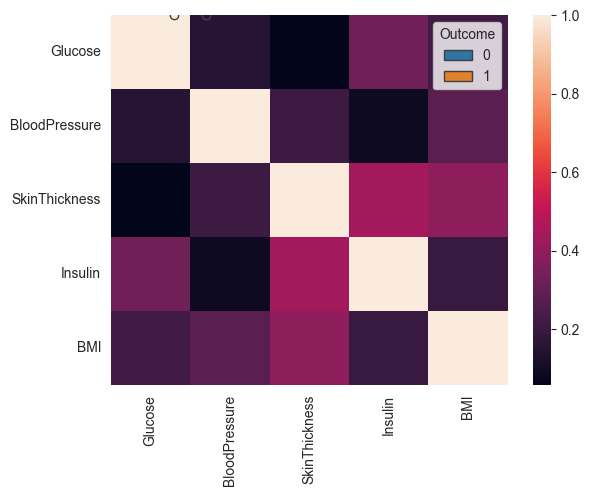

In [40]:
#diabetes.csv를 읽고, Outcome 값과, Age를 이용해서 BMI에 값을 box plot으로 표현
#Age가 30살 미만, 이상인지로 나누기
dia = pd.read_csv("diabetes.csv")
dia["Age2"] = dia.Age>=30  #np.where( dia.Age >=0, "Old", "Young")
sns.boxplot( x="Age2", y="BMI", hue="Outcome", data=dia)

#Glucose	BloodPressure	SkinThickness	Insulin	BMI	의 corr을 구해보시고, 히트맵으로 표현
sns.heatmap( dia.iloc[:, 1:6].corr() )

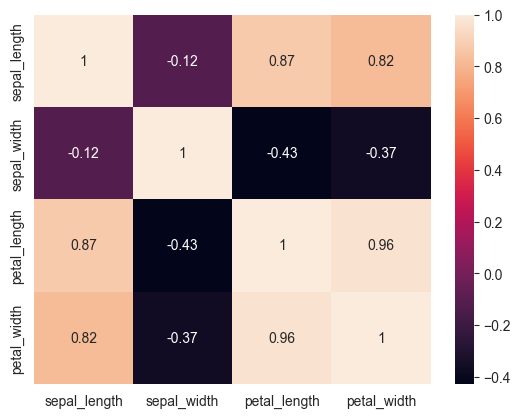

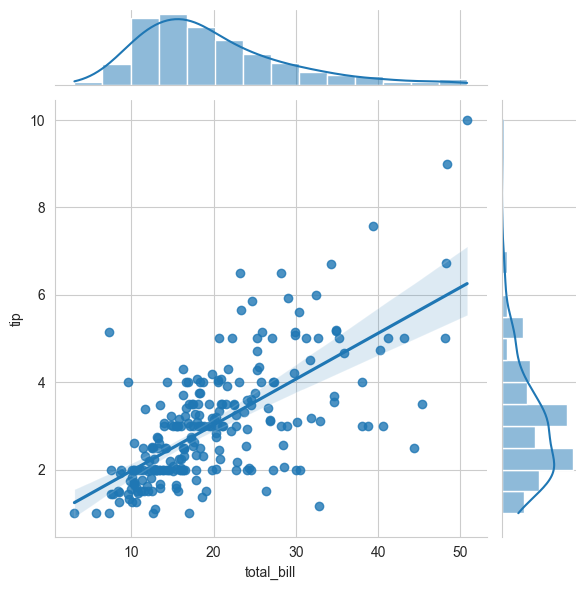

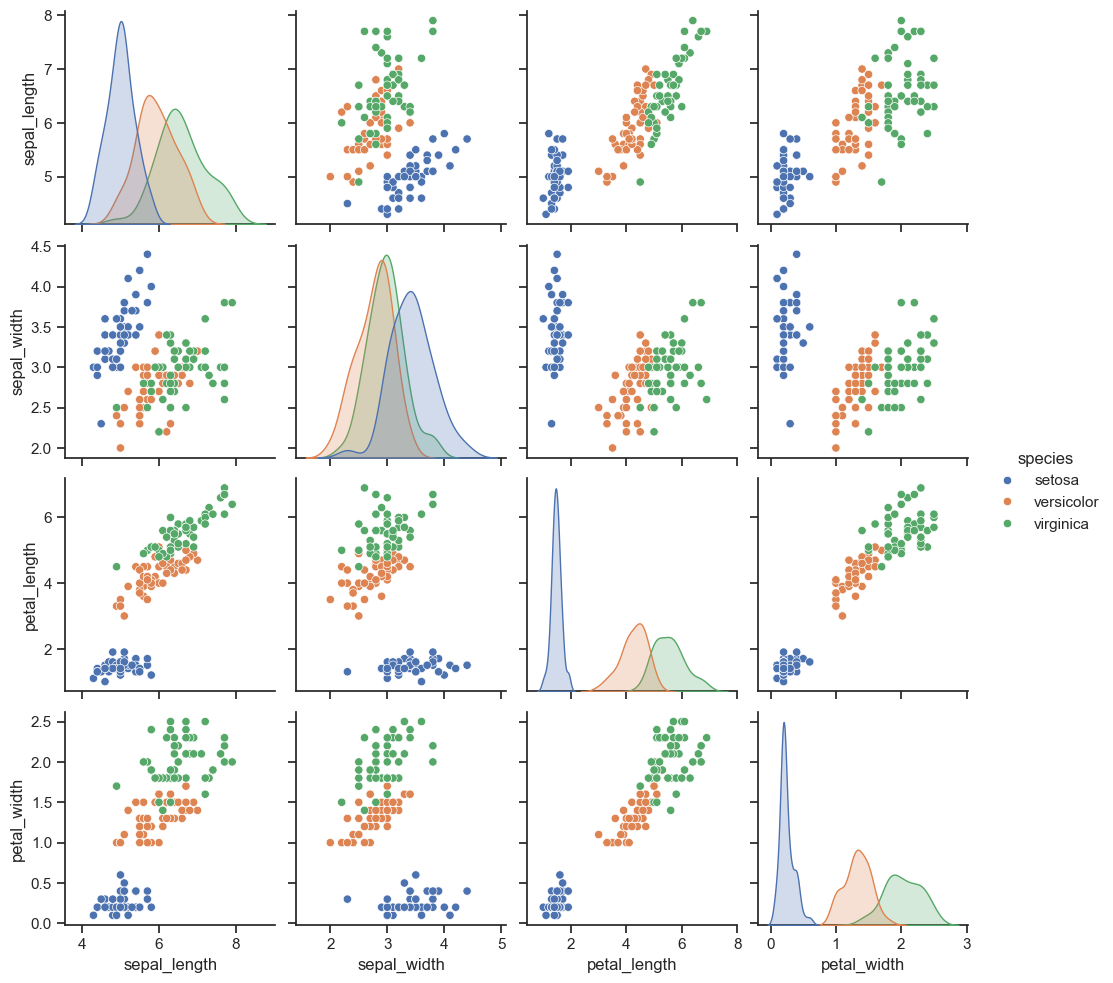

In [50]:
#heatmap+pandas
df.style.background_gradient(cmap='summer')
iris = sns.load_dataset("iris")

#heatmap+corr
corr=iris.drop(columns="species").corr()
corr
sns.heatmap(corr, annot=True)

#jointplot
sns.jointplot(x="total_bill", y="tip", data=tips, kind="reg");
plt.savefig('join3.png')

#pair plot
sns.set(style="ticks")
iris = sns.load_dataset("iris")
iris.head(10)

sns.pairplot(iris, hue="species")
plt.show()

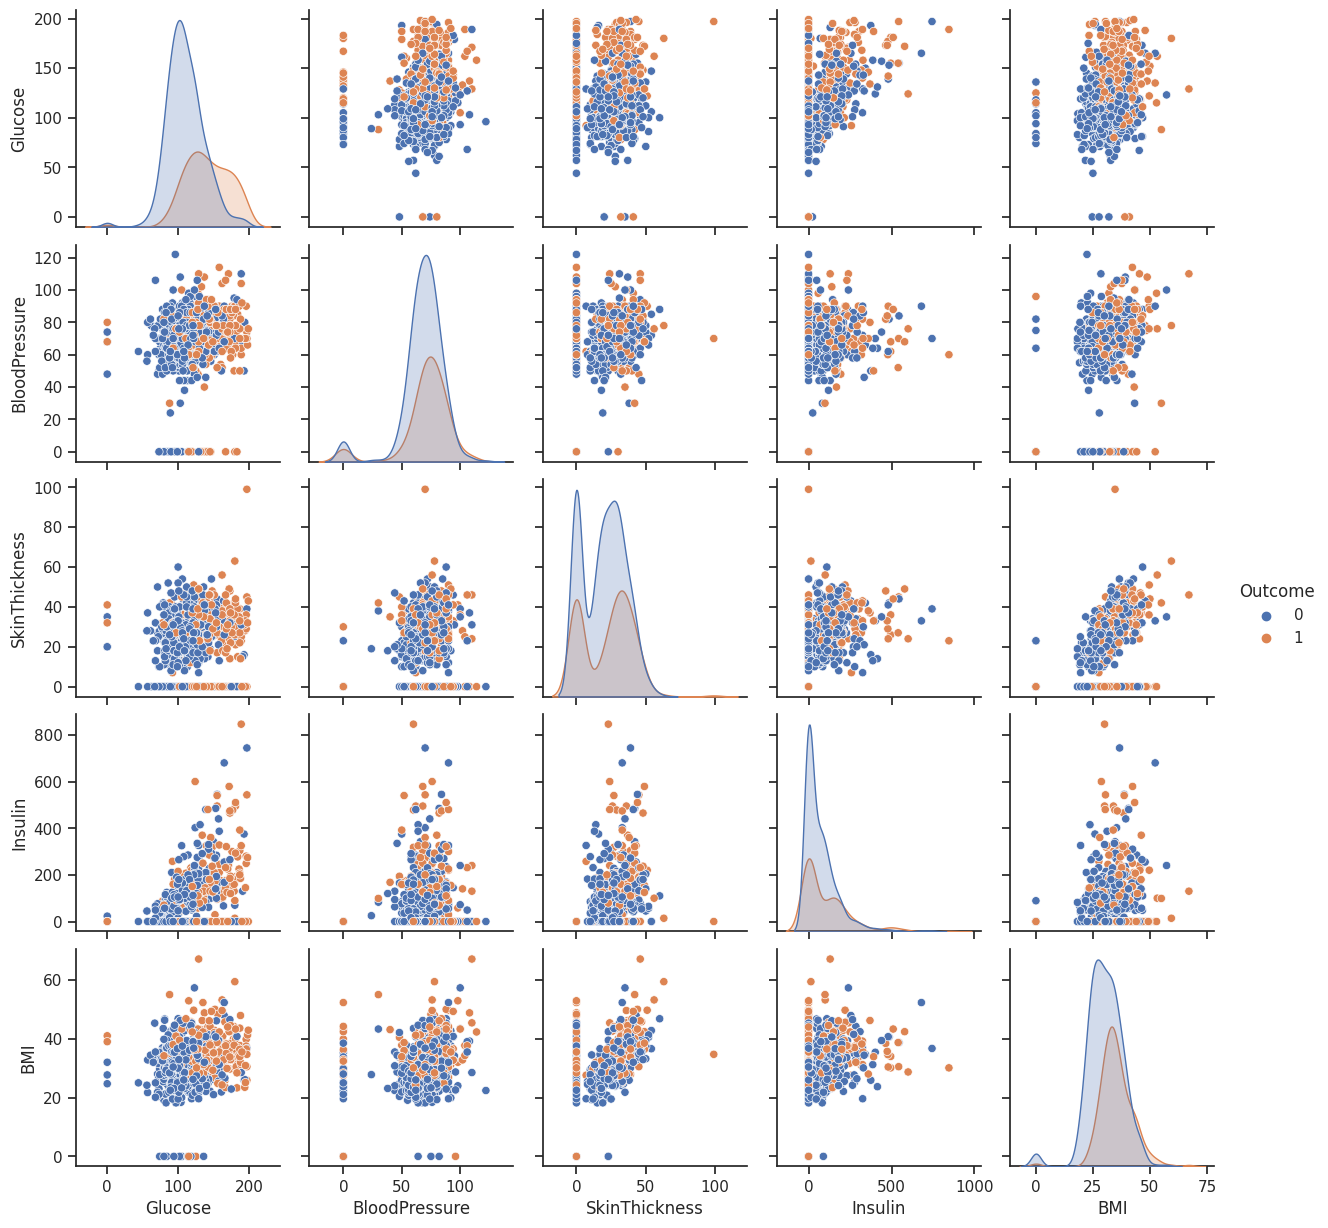

In [ ]:
#diabetes.csv 를 읽어서, Glucose	BloodPressure	SkinThickness	Insulin	BMI 변수들pairplot, 색상은 Outcome
sns.pairplot( dia[ ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Outcome" ]],
             hue="Outcome")

plt.savefig('out1.jpg')
#결과는 out1.jpg로 저장

- 선형관계의 시각화

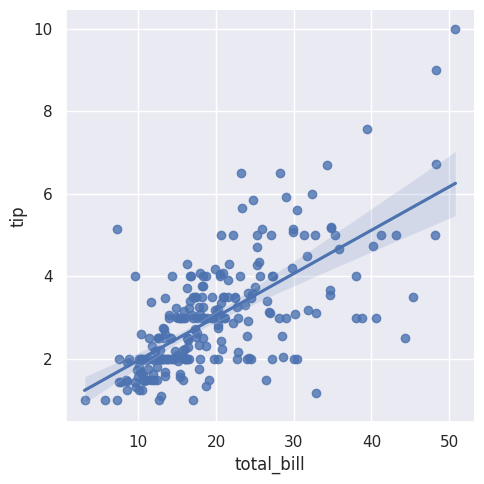

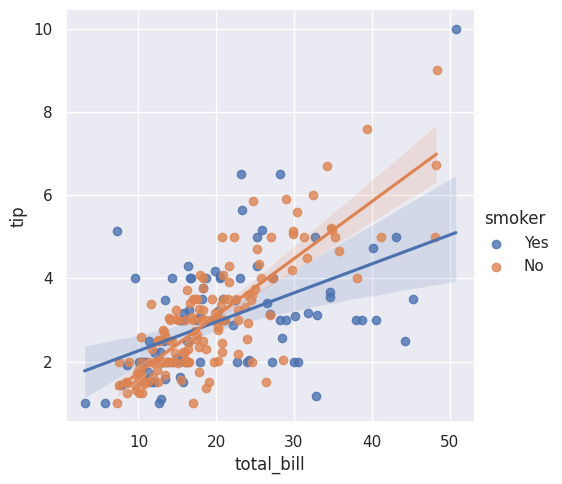

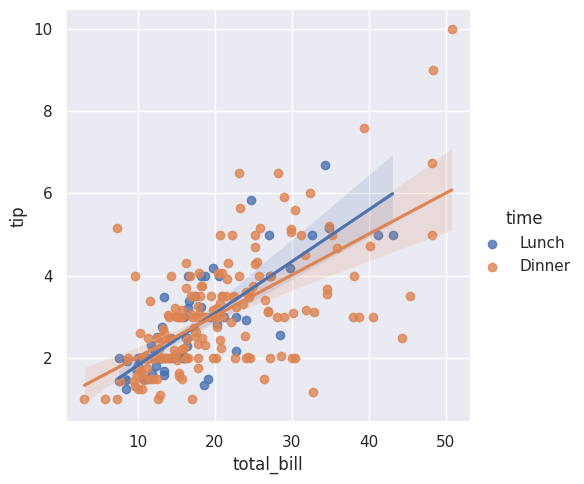

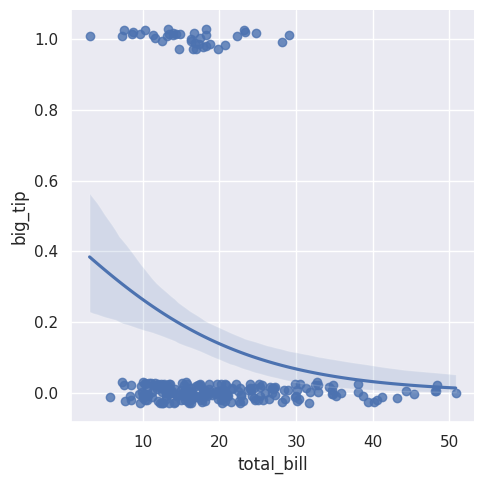

In [ ]:
#lm plot
sns.set_style("darkgrid")
sns.lmplot( x="total_bill", y="tip", data=tips)
plt.show()

#lm plot
sns.set_style("darkgrid")
sns.lmplot( x="total_bill", y="tip", data=tips, hue="smoker")
plt.show()

#lm plot
sns.set_style("darkgrid")
sns.lmplot( x="total_bill", y="tip", data=tips, hue="time")
plt.show()

#logistic regression 결과, binary 표시(20%기준)
tips['big_tip'] = tips['tip']/tips['total_bill'] >= 0.2
sns.lmplot(x="total_bill", y="big_tip", data=tips,logistic=True, y_jitter=.03);
plt.savefig("tiplogit.png")
